In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import calinski_harabasz_score
from sklearn.metrics import silhouette_samples

In [2]:
cluster_profiles = pd.read_parquet(
    "../data/processed/cluster_profiles.parquet"
)

In [3]:
print("Размер:", cluster_profiles.shape)

print(
    "Количество месячных кластеров:",
    len(cluster_profiles)
)

print(
    "Период:",
    cluster_profiles["date"].min(),
    "—",
    cluster_profiles["date"].max()
)

Размер: (521, 8)
Количество месячных кластеров: 521
Период: 2023-01-01 00:00:00 — 2024-12-01 00:00:00


In [4]:
model_features = [
    "food_share",
    "health_share",
    "marketplaces_share",
    "catering_share",
    "transport_share"
]

X_types = cluster_profiles[
    model_features
].to_numpy()

In [5]:
k_values = range(3, 11)

type_results = []

for k in k_values:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels_k = model.fit_predict(X_types)

    silhouette = silhouette_score(
        X_types,
        labels_k
    )

    calinski = calinski_harabasz_score(
        X_types,
        labels_k
    )

    type_results.append({
        "k": k,
        "silhouette": silhouette,
        "calinski_harabasz": calinski
    })

type_results_df = pd.DataFrame(type_results)

type_results_df

,k,silhouette,calinski_harabasz
0,3,0.399972,483.881608
1,4,0.377534,443.207457
2,5,0.365659,457.469265
3,6,0.352874,446.219092
4,7,0.346269,461.762500
5,8,0.340216,462.152377
6,9,0.317944,459.074968
7,10,0.318490,460.075424


In [6]:
cluster_sizes = cluster_profiles["n_municipalities"].to_numpy()

print("Минимальный размер:", cluster_sizes.min())
print("Медиана:", np.median(cluster_sizes))
print("Максимальный размер:", cluster_sizes.max())
print("Средний размер:", cluster_sizes.mean())

Минимальный размер: 2
Медиана: 94.0
Максимальный размер: 214
Средний размер: 96.96928982725528


In [7]:
weighted_results = []

k_values = range(3, 11)

for k in k_values:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels_k = model.fit_predict(
        X_types,
        sample_weight=cluster_sizes
    )

    silhouette = silhouette_score(
        X_types,
        labels_k
    )

    silhouette_values = silhouette_samples(
        X_types,
        labels_k
    )

    weighted_silhouette = np.average(
        silhouette_values,
        weights=cluster_sizes
    )

    calinski = calinski_harabasz_score(
        X_types,
        labels_k
    )

    weighted_results.append({
        "k": k,
        "silhouette": silhouette,
        "weighted_silhouette": weighted_silhouette,
        "calinski_harabasz": calinski
    })

weighted_results_df = pd.DataFrame(
    weighted_results
)

weighted_results_df

,k,silhouette,weighted_silhouette,calinski_harabasz
0,3,0.399223,0.401002,481.948757
1,4,0.346434,0.347566,430.723798
2,5,0.333947,0.341872,403.507192
3,6,0.321815,0.330186,385.654852
4,7,0.333815,0.336292,421.074363
5,8,0.321529,0.327038,410.391235
6,9,0.301907,0.304660,391.615079
7,10,0.288577,0.293260,373.128181


In [8]:
comparison = type_results_df.merge(
    weighted_results_df,
    on="k",
    suffixes=("_unweighted", "_weighted")
)

comparison

,k,silhouette_unweighted,calinski_harabasz_unweighted,silhouette_weighted,weighted_silhouette,calinski_harabasz_weighted
0,3,0.399972,483.881608,0.399223,0.401002,481.948757
1,4,0.377534,443.207457,0.346434,0.347566,430.723798
2,5,0.365659,457.469265,0.333947,0.341872,403.507192
3,6,0.352874,446.219092,0.321815,0.330186,385.654852
4,7,0.346269,461.762500,0.333815,0.336292,421.074363
5,8,0.340216,462.152377,0.321529,0.327038,410.391235
6,9,0.317944,459.074968,0.301907,0.304660,391.615079
7,10,0.318490,460.075424,0.288577,0.293260,373.128181


In [9]:
final_k = 3

weighted_model = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=20
)

economic_type_labels = weighted_model.fit_predict(
    X_types,
    sample_weight=cluster_sizes
)

cluster_profiles_with_types = cluster_profiles.copy()

cluster_profiles_with_types["economic_type"] = (
    economic_type_labels
)

cluster_profiles_with_types.head()

,date,cluster,food_share,health_share,marketplaces_share,catering_share,transport_share,n_municipalities,economic_type
0,2023-01-01,0,0.714487,0.072052,0.109116,0.030464,0.073881,160,2
1,2023-01-01,1,0.658027,0.091985,0.087570,0.048268,0.114150,81,2
2,2023-01-01,2,0.642972,0.083364,0.104826,0.069114,0.099725,92,2
3,2023-01-01,3,0.679651,0.081093,0.132084,0.024224,0.082948,97,2
4,2023-01-01,4,0.739960,0.071853,0.065875,0.029745,0.092568,165,2


In [10]:
economic_type_profiles = (
    cluster_profiles_with_types
    .groupby("economic_type")[model_features]
    .mean()
    .round(3)
)

economic_type_profiles

,food_share,health_share,marketplaces_share,catering_share,transport_share
economic_type,,,,,
0,0.603,0.063,0.231,0.032,0.071
1,0.498,0.085,0.204,0.103,0.110
2,0.680,0.066,0.140,0.036,0.079


In [11]:
economic_type_weights = (
    cluster_profiles_with_types
    .groupby("economic_type")["n_municipalities"]
    .sum()
    .sort_index()
)

economic_type_weights

economic_type
0    20994
1    10800
2    18727
Name: n_municipalities, dtype: int64

In [12]:
economic_type_shares = (
    economic_type_weights
    / economic_type_weights.sum()
)

economic_type_shares

economic_type
0    0.415550
1    0.213772
2    0.370678
Name: n_municipalities, dtype: float64

In [13]:
cluster_type_map = (
    cluster_profiles_with_types[
        ["date", "cluster", "economic_type"]
    ]
    .drop_duplicates()
)

cluster_type_map.head()

,date,cluster,economic_type
0,2023-01-01,0,2
1,2023-01-01,1,2
2,2023-01-01,2,2
3,2023-01-01,3,2
4,2023-01-01,4,2


In [14]:
clusters_all = pd.read_parquet(
    "../data/processed/clusters_all_months.parquet"
)

clusters_all["date"] = pd.to_datetime(
    clusters_all["date"]
)

In [15]:
municipality_types = clusters_all.merge(
    cluster_type_map,
    on=["date", "cluster"],
    how="left"
)

print("Размер:", municipality_types.shape)

print(
    "Пропуски economic_type:",
    municipality_types["economic_type"].isna().sum()
)

Размер: (50521, 4)
Пропуски economic_type: 0


In [16]:
monthly_type_shares = (
    municipality_types
    .groupby(["date", "economic_type"])["territory_id"]
    .nunique()
    .reset_index(name="n_municipalities")
)

monthly_type_shares

,date,economic_type,n_municipalities
0,2023-01-01,0,191
1,2023-01-01,1,399
2,2023-01-01,2,1553
3,2023-02-01,0,338
4,2023-02-01,1,469
...,...,...,...
67,2024-11-01,1,536
68,2024-11-01,2,51
69,2024-12-01,0,1468
70,2024-12-01,1,500


In [17]:
monthly_type_shares["share"] = (
    monthly_type_shares
    .groupby("date")["n_municipalities"]
    .transform(
        lambda x: x / x.sum()
    )
)

monthly_type_shares

,date,economic_type,n_municipalities,share
0,2023-01-01,0,191,0.089127
1,2023-01-01,1,399,0.186188
2,2023-01-01,2,1553,0.724685
3,2023-02-01,0,338,0.157870
4,2023-02-01,1,469,0.219057
...,...,...,...,...
67,2024-11-01,1,536,0.255238
68,2024-11-01,2,51,0.024286
69,2024-12-01,0,1468,0.698050
70,2024-12-01,1,500,0.237756


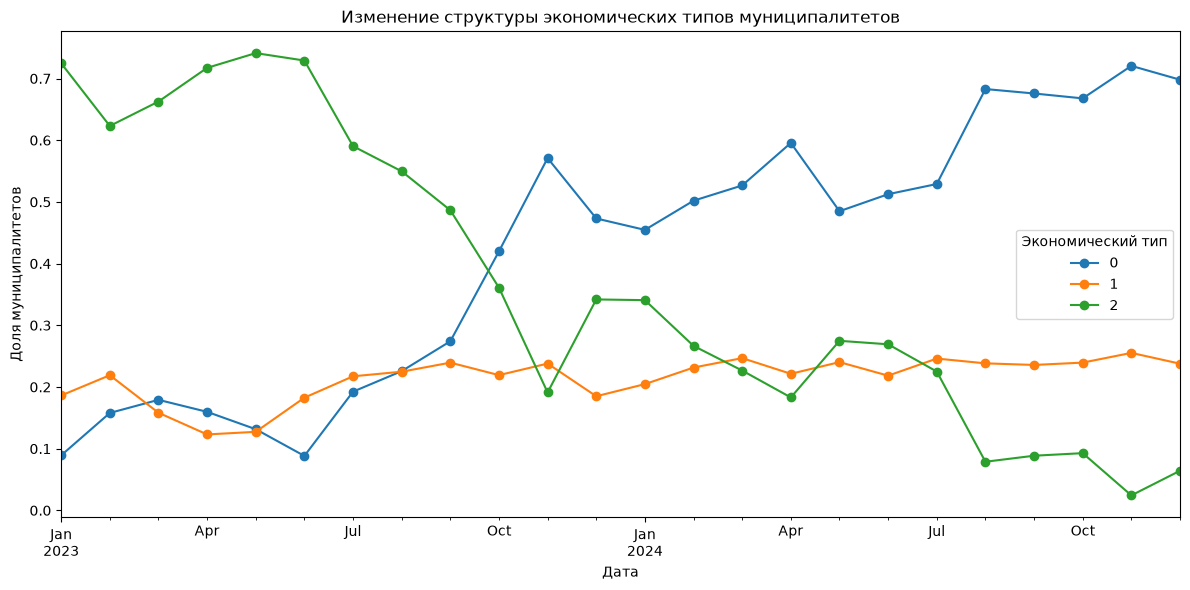

In [18]:
plot_data = (
    monthly_type_shares
    .pivot(
        index="date",
        columns="economic_type",
        values="share"
    )
)

plot_data.plot(
    figsize=(12, 6),
    marker="o"
)

plt.title(
    "Изменение структуры экономических типов муниципалитетов"
)

plt.xlabel("Дата")
plt.ylabel("Доля муниципалитетов")
plt.legend(
    title="Экономический тип"
)

plt.tight_layout()
plt.show()

In [19]:
municipality_types.to_parquet(
    "../data/processed/municipality_economic_types.parquet",
    index=False
)

economic_type_profiles.to_csv(
    "../data/processed/economic_type_profiles.csv",
    index=True
)

monthly_type_shares.to_csv(
    "../data/processed/monthly_economic_type_shares.csv",
    index=False
)

print("Итоговые результаты сохранены.")

Итоговые результаты сохранены.


In [20]:
comparison = comparison.rename(
    columns={
        "calinski_harabasz_weighted":
            "calinski_harabasz_after_weighted_fit"
    }
)

comparison

,k,silhouette_unweighted,calinski_harabasz_unweighted,silhouette_weighted,weighted_silhouette,calinski_harabasz_after_weighted_fit
0,3,0.399972,483.881608,0.399223,0.401002,481.948757
1,4,0.377534,443.207457,0.346434,0.347566,430.723798
2,5,0.365659,457.469265,0.333947,0.341872,403.507192
3,6,0.352874,446.219092,0.321815,0.330186,385.654852
4,7,0.346269,461.762500,0.333815,0.336292,421.074363
5,8,0.340216,462.152377,0.321529,0.327038,410.391235
6,9,0.317944,459.074968,0.301907,0.304660,391.615079
7,10,0.318490,460.075424,0.288577,0.293260,373.128181
